# Grammatical complexity
Here we calculate G (Jamieson & Mewhort, 2005).

The steps are:

1. Use elbow method to find optimal number k of clusters
2. Do K-means clustering to find bins (for each participant individually)
3. Calculate G for each participant
    - Loop over participants
    - Discretize the data into k bins
    - Calculate entropy
        U = -np.sum(np.log2(p_{ij}) * p_{ij})  # so if p is a 2-D array, we can do the whole thing at once
    - Calculate G = 1 - U(targetgrammar) / U(referencegrammar)

_Note._ p_{ij} denotes the probability of symbol j following symbol i

Reference: Jamieson, R. K., & Mewhort, D. J. K. (2005). The influence of grammatical, local, and organizational redundancy on implicit learning: An analysis using information theory. _Journal of Experimental Psychology_: Learning, Memory, and Cognition, _31_, 9–23.

## 0. Preliminaries

In [93]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import scipy.stats
import os

# Load data
raw_df = pd.read_csv(os.path.join('Dataframes', 'ITIs.csv'))

We remove responses that are > 1200 ms.

In [94]:
clean_df = raw_df[raw_df.resp_iti < 1200]

We split the data according to the tempo _before_ we do the Elbow.

In [95]:
# Split data
df_400 = clean_df[clean_df.stim_tempo_intended == 400]
print(df_400.head(5))
df_600 = clean_df[clean_df.stim_tempo_intended == 600]
dfs = {'400 ms': df_400, '600 ms': df_600}

    Unnamed: 0  pp_id  age gender      L1 handedness  musical_experience  \
4            5      1   22      F  Danish      right                 1.0   
5            6      1   22      F  Danish      right                 1.0   
6            7      1   22      F  Danish      right                 1.0   
11          12      1   22      F  Danish      right                 1.0   
12          13      1   22      F  Danish      right                 1.0   

    stim_id sequence_id  length  n_resp  stim_tempo_intended  stim_tempo  \
4         2         1_2       4       4                  400  493.822844   
5         2         1_2       4       4                  400  493.822844   
6         2         1_2       4       4                  400  493.822844   
11        4         1_4       5       5                  400  519.764398   
12        4         1_4       5       5                  400  519.764398   

       stim_sd  interval_i    stim_ioi    resp_iti  ioi_iti_diff  
4   146.950240     

## 1. Elbow

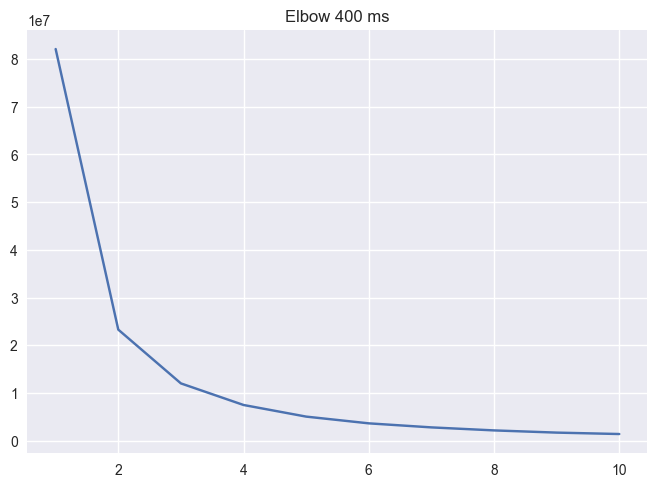

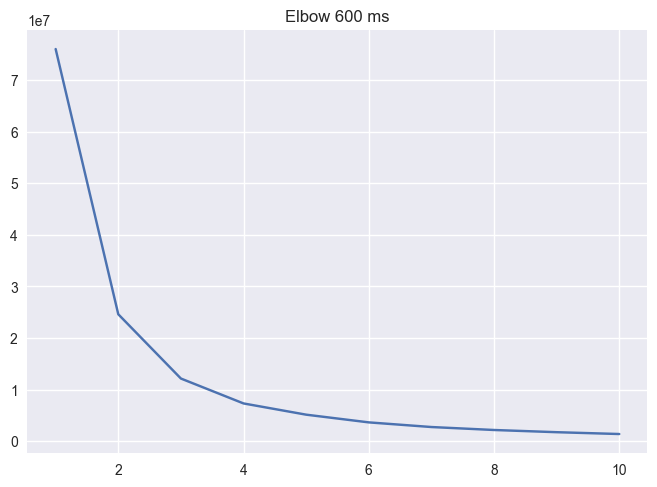

In [96]:
import warnings
warnings.filterwarnings('ignore')

for tempo, df in dfs.items():
    all_resps = df.resp_iti.values
    all_resps = all_resps.reshape(-1, 1)
    wcss = []
    for i in range(1, 11):
        clustering = KMeans(n_clusters=i, init='k-means++')
        clustering.fit(all_resps)
        wcss.append(clustering.inertia_)

    ks = np.arange(1,11)
    plt.plot(ks, wcss)
    plt.title(f'Elbow {tempo}')
    plt.show()

## Calculate cluster centers for each participant
Here, we:

* Loop over the tempi
* Loop over the participants
* Do K-means clustering
* Add to output DataFrame

The data structure we're looking for is a DataFrame that looks like:

```
pp_id   tempo   cluster_center_0    cluster_center_1    cluster_center_2
10      400     100                 200                 400
```

In addition, we get the middle between the clusters and use that as the left boundary for the bins. So in the above examples the bins become (0, 150], (150, 300], (300, inf)

In [97]:
df_clusters = pd.DataFrame()

for tempo, df in dfs.items():
    for pp_id in df.pp_id.unique():
        pp_data = df[df.pp_id == pp_id]
        data = pp_data.resp_iti.values.reshape(-1, 1)  # Reshape 1-D data
        kmeans = KMeans(n_clusters=3, max_iter=1000)
        kmeans.fit(data)
        kmeans_clusters = sorted(kmeans.cluster_centers_)
        pp_df = pd.DataFrame({
            'pp_id': pp_id,
            'tempo': tempo,
            'cluster_center_0': kmeans_clusters[0],
            'cluster_center_1': kmeans_clusters[1],
            'cluster_center_2': kmeans_clusters[2],
            'bin_left_boundary_0': kmeans_clusters[0] + (kmeans_clusters[1] - kmeans_clusters[0]) / 2,  # get the middle between the centers
            'bin_left_boundary_1': kmeans_clusters[1] + (kmeans_clusters[2] - kmeans_clusters[1]) / 2   # get the middle between the centers
        })
        df_clusters = pd.concat([df_clusters, pp_df])

df_clusters



,pp_id,tempo,cluster_center_0,cluster_center_1,cluster_center_2,bin_left_boundary_0,bin_left_boundary_1
0,1,400 ms,253.310539,461.477273,692.192875,357.393906,576.835074
0,10,400 ms,239.404125,413.970427,594.488636,326.687276,504.229532
0,11,400 ms,258.206388,459.678030,639.585095,358.942209,549.631563
0,12,400 ms,242.107438,430.963326,574.802807,336.535382,502.883067
0,2,400 ms,257.167969,561.327886,742.640100,409.247927,651.983993
0,3,400 ms,252.228941,461.963979,633.930481,357.096460,547.947230
0,4,400 ms,227.312253,382.159091,556.858852,304.735672,469.508971
0,5,400 ms,228.654016,368.487461,528.358586,298.570738,448.423023
0,7,400 ms,238.450413,426.021602,590.327173,332.236008,508.174387
0,8,400 ms,256.561584,456.697214,619.318182,356.629399,538.007698


## 3. Calculate G for each participant
The constrained grammar is the grammar of the participant. The unconstrained grammar is one in which each symbol can follow each symbol with equal probability.

* We make a k x k (i x j) array (i.e. here 3 x 3) that initially looks like:

```
          0 short  1 medium  2 long
0 short   0        0         0
1 medium  0        0         0
2 long    0        0         0
```

* We loop over the tempi
* We loop over the participants
* We loop over the sequences
* We loop over the ITIs
* We digitize according to the participant's bins (that come from the K-means clustering)
* We update the relevant freq for each pair of ITIs
* We calculate the probabilities based on the frequencies
* We calculate the uncertainty U
* We calculate G using the constrained grammar's U, and the unconstrained grammar's U (i.e. equal probabilities for each combination of i and j)

In [98]:
freqs = {'400 ms': {},
         '600 ms': {}}

probabilities_unconstrained = np.array([1/9] * 9)
U_unconstrained = scipy.stats.entropy(probabilities_unconstrained)

G_df = pd.DataFrame(columns=['pp_id', 'tempo', 'G'])

# Loop over two tempi
for tempo in freqs.keys():
    df_tempo = dfs[tempo]
    # Loop over participants
    for pp_id in df_tempo.pp_id.unique():
        pp_bins_df = df_clusters[(df_clusters.pp_id == pp_id) & (df_clusters.tempo == tempo)]
        pp_bin_left_boundaries = np.array([pp_bins_df.bin_left_boundary_0.values[0],
                                           pp_bins_df.bin_left_boundary_1.values[0]])
        df_pp = df_tempo[df_tempo.pp_id == pp_id]
        # Make empty k by k array
        freqs_pp = np.zeros((3, 3))
        # Loop over sequences
        for sequence_id in df_pp.sequence_id.unique():
            seq_itis = df_pp[df_pp.sequence_id == sequence_id].resp_iti.values
            # Digitize
            itis_digitized = np.digitize(seq_itis, bins=pp_bin_left_boundaries)
            # Increase frequency of relevant position in matrix by one
            for index in range(len(itis_digitized) - 1):
                i = itis_digitized[index]
                j = itis_digitized[index + 1]
                freqs_pp[i, j] += 1

        probabilities_pp = freqs_pp / np.sum(freqs_pp)
        U_pp = scipy.stats.entropy(probabilities_pp.flatten())
        G_pp = 1 - (U_pp / U_unconstrained)
        pp_df = pd.DataFrame({
            'pp_id': pp_id,
            'tempo': tempo,
            'G': G_pp
        }, index=[0])

        G_df = pd.concat([G_df, pp_df], ignore_index=True)

G_df.sort_values(by=['pp_id', 'tempo']).reset_index(drop=True)

G_df

,pp_id,tempo,G
0,1,400 ms,0.114332
1,10,400 ms,0.019791
2,11,400 ms,0.027135
3,12,400 ms,0.041025
4,2,400 ms,0.035924
5,3,400 ms,0.005060
6,4,400 ms,0.021972
7,5,400 ms,0.044104
8,7,400 ms,0.046356
9,8,400 ms,0.058368


Plot individual differences:

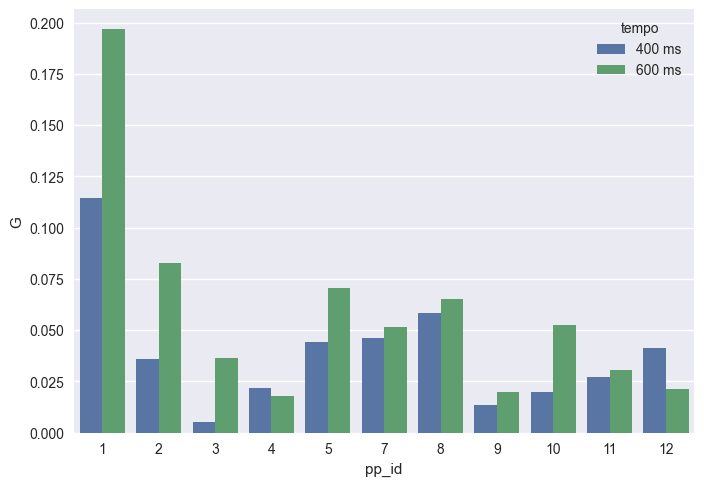

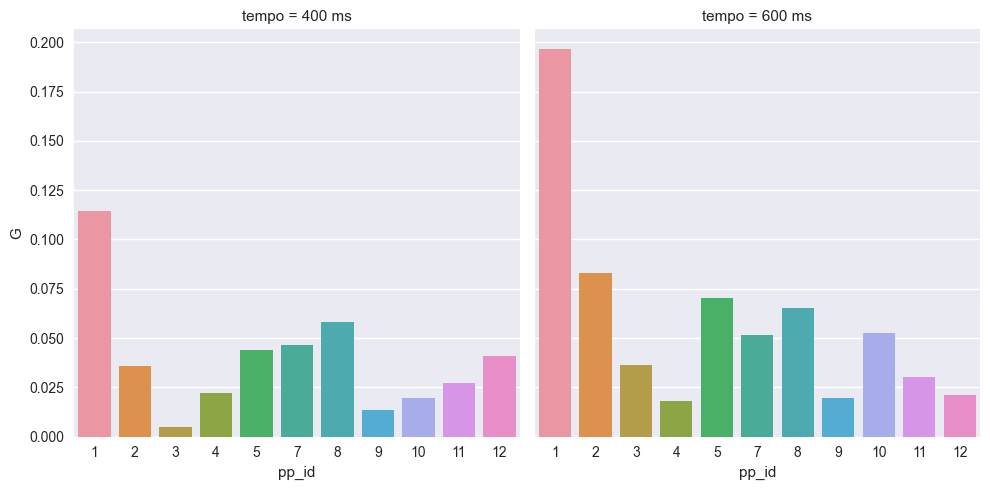

In [99]:
import seaborn as sns

plot = sns.barplot(data=G_df, x='pp_id', y='G', hue='tempo');
plot2 = sns.catplot(data=G_df, x='pp_id', y='G', col='tempo', kind='bar')